# Econ 372 — Homework

Renee Ngai

In [3]:
import pandas as pd
import numpy as np

# The data lives in the data/ folder at the top of the repo. From this
df = pd.read_csv(r"C:\Users\ngair\Downloads\nj_ihc_family_premiums_2000_2008.csv")

In [4]:
df.head()

,Year,Horizon_BCBSNJ_PlanD_1000Ded_Family_MonthlyPremium,Aetna_PlanD_1000Ded_Family_MonthlyPremium,Celtic_PlanC_2500Ded_Family_MonthlyPremium,IHC_TotalYearEnd_Standard_Enrollment
0,2000,1676.90,2949.0,2551.0,98769
1,2001,2072.39,4312.0,3188.0,84968
2,2002,2765.07,4266.0,4003.0,78698
3,2003,3573.71,4266.0,7843.0,75839
4,2004,4437.96,4390.0,7843.0,75047


## Question 1

Write your code and your answer here.

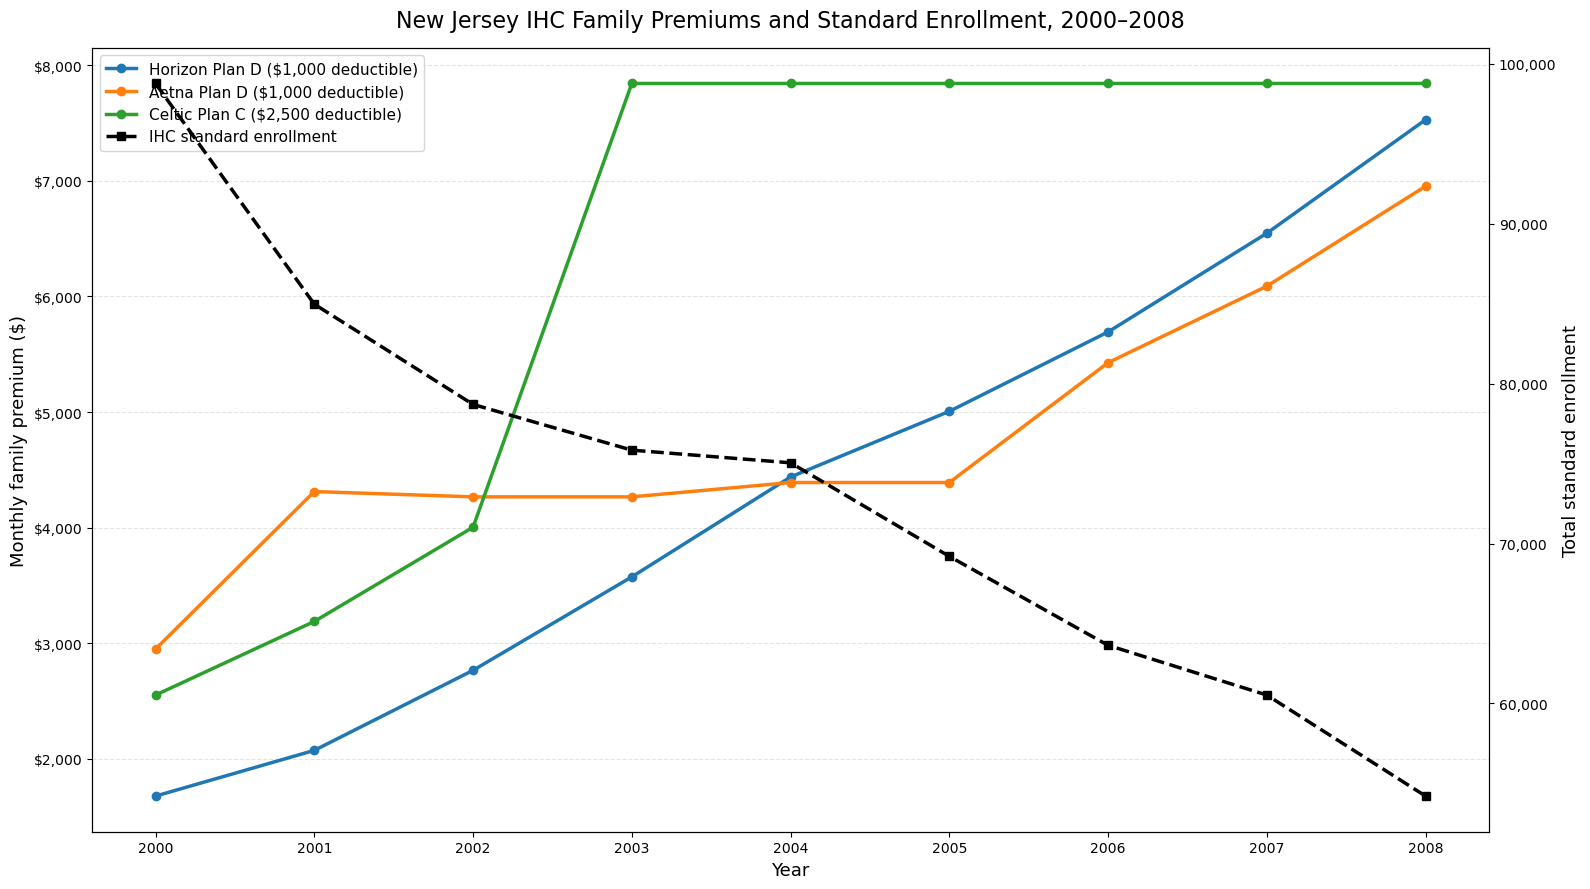

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, MaxNLocator

fig, ax1 = plt.subplots(figsize=(16, 9))

premium_columns = {
    "Horizon Plan D ($1,000 deductible)": "Horizon_BCBSNJ_PlanD_1000Ded_Family_MonthlyPremium",
    "Aetna Plan D ($1,000 deductible)": "Aetna_PlanD_1000Ded_Family_MonthlyPremium",
    "Celtic Plan C ($2,500 deductible)": "Celtic_PlanC_2500Ded_Family_MonthlyPremium",
}

for label, column in premium_columns.items():
    ax1.plot(
        df["Year"],
        df[column],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=label
    )

ax1.set_xlabel("Year", fontsize=13)
ax1.set_ylabel("Monthly family premium ($)", fontsize=13)
ax1.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.grid(axis="y", linestyle="--", alpha=0.35)

ax2 = ax1.twinx()
ax2.plot(
    df["Year"],
    df["IHC_TotalYearEnd_Standard_Enrollment"],
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.5,
    markersize=6,
    label="IHC standard enrollment"
)

ax2.set_ylabel("Total standard enrollment", fontsize=13)
ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax1.set_title(
    "New Jersey IHC Family Premiums and Standard Enrollment, 2000–2008",
    fontsize=16,
    pad=15
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    fontsize=11,
    frameon=True
)

fig.tight_layout()
plt.show()

b. Description: The graphs shows NJ IHC Family Premiums and Enrollment from the year 2000-2008. The graph shows that IHC total year end standard enrollment and total enrollment shows a steady decline from 2000-2008. On the other hand, Aetna Plan D, horizon Plan D, and Celtic Plan C shows a slight increasing trend from 2000-2008.

c. This graph is an evidence of adverse selection because as the three insurance premiums  (Aetna, Celtic, and Horizon) rise from 2000 to 8000, households who are healthy switch to chaper alternatives, as sshown by the declining IHc standard enrollment from 100,000 to 60,000. The pool worsens to only sicker populations, causing the insurance premiums to rise again. Therefore, insurance premium increases occur hand in hand with declining enrollment.

d. Weighing against the adverse selection explanation, this is not a death spiral as shown by the data. From the graph, The IHC total year end standard enrollment decreases steadily, not suddenly from 100,000 to 60,000 as the monthly premium from the insurance plan increases drastically from 2000 to 8000. This uniform trend across plan contradicts with the sudden drop in enrollment after drastic family premium increases.  Alternative explanations for this enrollment trend is the underlying medical cost growth in New Jersey as well as regulatory constraints in the New Jersey IHC market that leads to uniform premium increases from 2000-2008.

## Question 2

Write your code and your answer here.

In [6]:
ma = pd.read_csv(r"C:\Users\ngair\Downloads\medicare-ma-penetration.csv")
ffs = pd.read_csv(r"C:\Users\ngair\Downloads\medicare-ffs-costs.csv")

In [7]:
ma.head()

,fips,state,county,year,total_eligibles,ma_enrolled
0,1001,AL,AUTAUGA,2008,7589,2057.0
1,1001,AL,AUTAUGA,2009,7870,2363.0
2,1001,AL,AUTAUGA,2010,8167,2195.0
3,1001,AL,AUTAUGA,2011,8509,2386.0
4,1001,AL,AUTAUGA,2012,8969,2652.0


In [8]:
ffs.head()

,fips,state,county,year,ffs_enrollment,ffs_spending
0,1001,AL,AUTAUGA,2008,4214.0,33123019.0
1,1001,AL,AUTAUGA,2009,4125.0,30547571.0
2,1001,AL,AUTAUGA,2010,4504.0,33213585.0
3,1001,AL,AUTAUGA,2011,4648.0,36147956.0
4,1001,AL,AUTAUGA,2012,4751.0,35987007.0


In [9]:
df_merged = pd.merge(
    ma,
    ffs,
    on=["county", "year"],
    how="inner"
)

df_merged.head()

,fips_x,state_x,county,year,total_eligibles,ma_enrolled,fips_y,state_y,ffs_enrollment,ffs_spending
0,1001,AL,AUTAUGA,2008,7589,2057.0,1001,AL,4214.0,33123019.0
1,1001,AL,AUTAUGA,2009,7870,2363.0,1001,AL,4125.0,30547571.0
2,1001,AL,AUTAUGA,2010,8167,2195.0,1001,AL,4504.0,33213585.0
3,1001,AL,AUTAUGA,2011,8509,2386.0,1001,AL,4648.0,36147956.0
4,1001,AL,AUTAUGA,2012,8969,2652.0,1001,AL,4751.0,35987007.0


In [10]:
national = (
    df_merged.groupby("year")
    .agg({
        "ma_enrolled": "sum",
        "total_eligibles": "sum",
        "ffs_spending": "sum",
        "ffs_enrollment": "sum"
    })
    .reset_index()
)

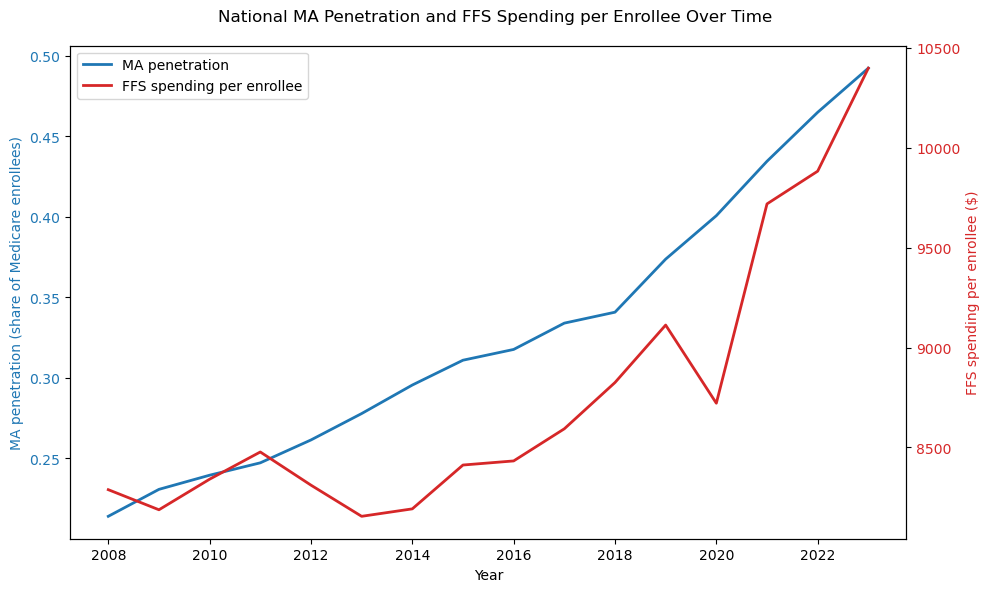

In [11]:
# National MA penetration:
#   ma_penetration = sum(ma_enrollees) / sum(total_medicare_enrollees)
national["ma_penetration"] = (
    national["ma_enrolled"] / national["total_eligibles"]
)

# National FFS spending per enrollee:
#   ffs_spending_per_enrollee = sum(ffs_spending_total) / sum(ffs_enrollees)
national["ffs_spending_per_enrollee"] = (
    national["ffs_spending"] / national["ffs_enrollment"]
)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    national["year"],
    national["ma_penetration"],
    color="tab:blue",
    linewidth=2,
    label="MA penetration"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("MA penetration (share of Medicare enrollees)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(
    national["year"],
    national["ffs_spending_per_enrollee"],
    color="tab:red",
    linewidth=2,
    label="FFS spending per enrollee"
)
ax2.set_ylabel("FFS spending per enrollee ($)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.suptitle("National MA Penetration and FFS Spending per Enrollee Over Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
plt.show()


a. Describe the trends: the graph shows that MA penetration and FFS spending per enrollee is both increasing from the year 2008-2022. From 2013-2024 and 2019-2022, FFS spending per enrollee showed a small decline and rebound but MA penetration continues to increase at a steady rate. 

b. Looking at the MA penetration and FFS spending per enrollee patterns together, during the COVID-19 pandemic there was a sharp decline in FFS spending. The pattern suggests that healthier individuals move towards MA and sicker individuals stay in FFS. 

c. (3 points) Risk adjustment. What is risk adjustment, as we covered it in class, and what problem does it aim to address in the Medicare Advantage market?

Risk adjustment is adjusting payments and insurance premiums based on health status and expected costs. It aims to address the sicker population with more expensive medical costs in the medicare Advantage Market by calculating a risk adjustment score for everyone enrollled in the Medicare advantage program instead of having each Medicare advantage enrollee paying the same fee.

d. (3 points) Beyond risk adjustment. Risk adjustment is not the only tool to combat adverse selection. Find one other policy that has been used or proposed to limit selection in Medicare Advantage, or to hold down fee-for-service costs, cite the source where you read about it, and explain in a few sentences how it would help. Use a credible health-policy source such as KFF, the Commonwealth Fund, Health Affairs, or a MedPAC report, not a general website or blog.


Another policy that has been proposed to limit selection in Medicare Advantage is the CMS Medicare Advantage and Section 1876 Cost Plan Network Adequacy Guidance, which requires Medicare Advantage plans to meet minimum provider and facility availability standards across specialties. This limits adverse selection becasue it prevents a health only network desgin and ensures access for patients with higher medical needs.

Source: https://www.cms.gov/files/document/medicare-advantage-and-section-1876-cost-plan-network-adequacy-guidance-12-09-2024.pdf?utm_source=copilot.com